In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:


file_path = "/content/housing.csv"   # Change dataset path

# Auto detect file type
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path)
elif file_path.endswith(".xlsx"):
    df = pd.read_excel(file_path)
else:
    raise ValueError("Only CSV and Excel files are supported")

print("\nDataset Loaded Successfully")
print("Shape :", df.shape)


Dataset Loaded Successfully
Shape : (20640, 10)


In [ ]:

duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)

print(f"\nDuplicates Removed : {duplicates}")


Duplicates Removed : 0


In [ ]:

for col in df.columns:

    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())

    else:
        mode_value = df[col].mode()

        if len(mode_value) > 0:
            df[col] = df[col].fillna(mode_value[0])
        else:
            df[col] = df[col].fillna("Unknown")

print("\nMissing Values Handled")


Missing Values Handled


In [ ]:

numeric_cols = df.select_dtypes(include=np.number).columns

initial_rows = len(df)

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

final_rows = len(df)

print(f"\nRows Removed By IQR : {initial_rows - final_rows}")


Rows Removed By IQR : 3744


In [ ]:


constant_cols = [col for col in df.columns if df[col].nunique() <= 1]

if constant_cols:
    df.drop(columns=constant_cols, inplace=True)

print("\nConstant Columns Removed :", constant_cols)


Constant Columns Removed : []


In [ ]:


df.reset_index(drop=True, inplace=True)

In [ ]:


print("\nFinal Shape :", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Final Shape : (16896, 10)

Missing Values After Cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64



Cleaned Dataset Saved Successfully


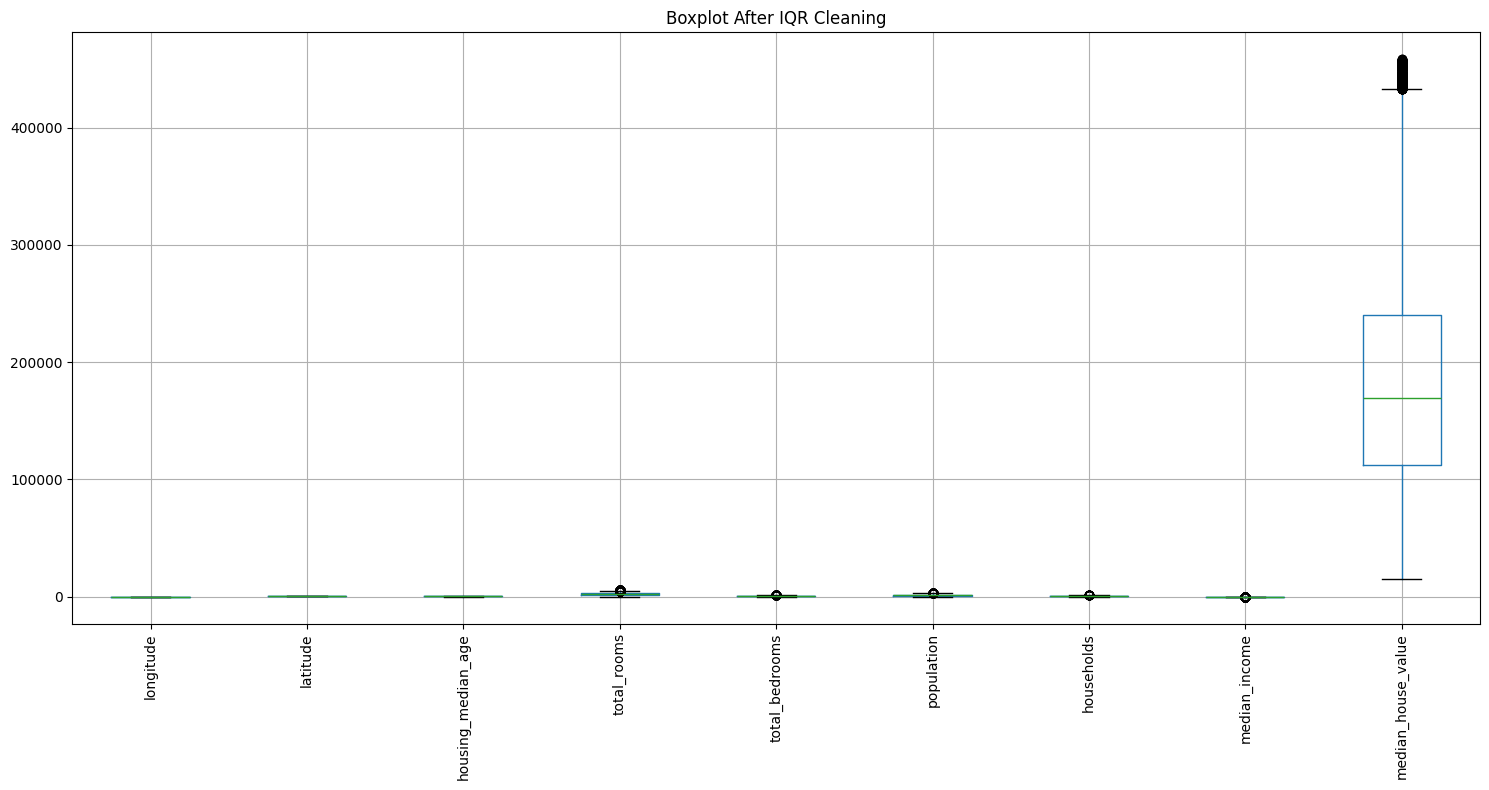

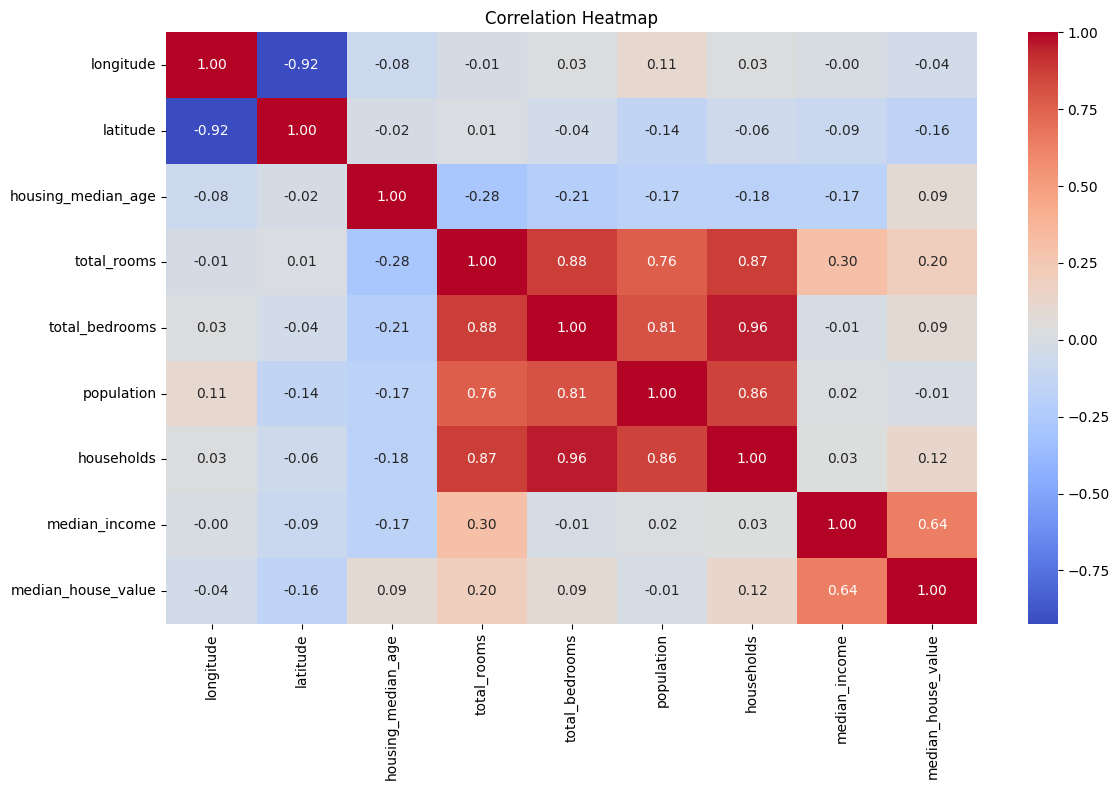


Data Cleaning Completed Successfully


In [ ]:


df.to_csv("cleaned_dataset.csv", index=False)

print("\nCleaned Dataset Saved Successfully")



if len(numeric_cols) > 0:

    plt.figure(figsize=(15,8))
    df[numeric_cols].boxplot(rot=90)
    plt.title("Boxplot After IQR Cleaning")
    plt.tight_layout()
    plt.show()



if len(numeric_cols) > 1:

    plt.figure(figsize=(12,8))
    sns.heatmap(
        df[numeric_cols].corr(),
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

print("\nData Cleaning Completed Successfully")

In [ ]:
# Load Dataset
df = pd.read_csv("/content/cleaned_dataset.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
1,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
2,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
3,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
4,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
16891,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
16892,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
16893,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
16894,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [ ]:
X = df.drop(['median_house_value', 'ocean_proximity'], axis=1)
y = df['median_house_value']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.5979724588100397
MSE: 3375454259.702783
